<a href="https://colab.research.google.com/github/qichinnn/FundamentalAI_2026A/blob/main/Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Q3_Student_Dataset_DT_KNN_Noise.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

# Display information about the DataFrame, including column names and data types
print('\nDataFrame Info:')
df.info()

First 5 rows of the dataset:


,Student_ID,Attendance_Percent,Assignment_Avg,Quiz_Avg,Final_Result
0,S01,83,55,43,Fail
1,S02,95,52,92,Fail
2,S03,70,55,50,Pass
3,S04,49,86,55,Fail
4,S05,68,84,63,Pass



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Student_ID          30 non-null     object
 1   Attendance_Percent  30 non-null     int64 
 2   Assignment_Avg      30 non-null     int64 
 3   Quiz_Avg            30 non-null     int64 
 4   Final_Result        30 non-null     object
dtypes: int64(3), object(2)
memory usage: 1.3+ KB


### 1. Label Encoding for the Target Variable (`Final_Result`)

In [2]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to the 'Final_Result' column
df['Final_Result_Encoded'] = le.fit_transform(df['Final_Result'])

# Display the mapping of original labels to encoded values
print("Original labels and their encoded values:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

# Display the first few rows with the new encoded column
print('\nFirst 5 rows with encoded Final_Result:')
display(df[['Final_Result', 'Final_Result_Encoded']].head())

Original labels and their encoded values:
Fail: 0
Pass: 1

First 5 rows with encoded Final_Result:


,Final_Result,Final_Result_Encoded
0,Fail,0
1,Fail,0
2,Pass,1
3,Fail,0
4,Pass,1


### 2. Feature Scaling for Numerical Input Features

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score

# Define features (X) and target (y)
# We'll use the scaled numerical features as X
X = df[numerical_features]
# We'll use the encoded target variable as y
y = df['Final_Result_Encoded']

# Split the data into training and testing sets
# Using stratify=y to ensure that the proportion of 'Pass' and 'Fail' is similar in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

# Initialize and train a K-Nearest Neighbors (KNN) model
# We'll start with n_neighbors=3, a common choice
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn_model.predict(X_test)

# Evaluate the model using the classification report, which includes F1-Score
# We'll map the encoded labels back to original labels for better readability in the report
target_names = ['Fail', 'Pass'] # Assuming 0: Fail, 1: Pass from LabelEncoder output

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=target_names))

# Explicitly print the weighted F1-score for overall performance
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Weighted F1-Score: {weighted_f1:.4f}")

Training set shape: (24, 3), (24,)
Testing set shape: (6, 3), (6,)

Classification Report:
              precision    recall  f1-score   support

        Fail       0.50      0.33      0.40         3
        Pass       0.50      0.67      0.57         3

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.50      0.50      0.49         6

Weighted F1-Score: 0.4857


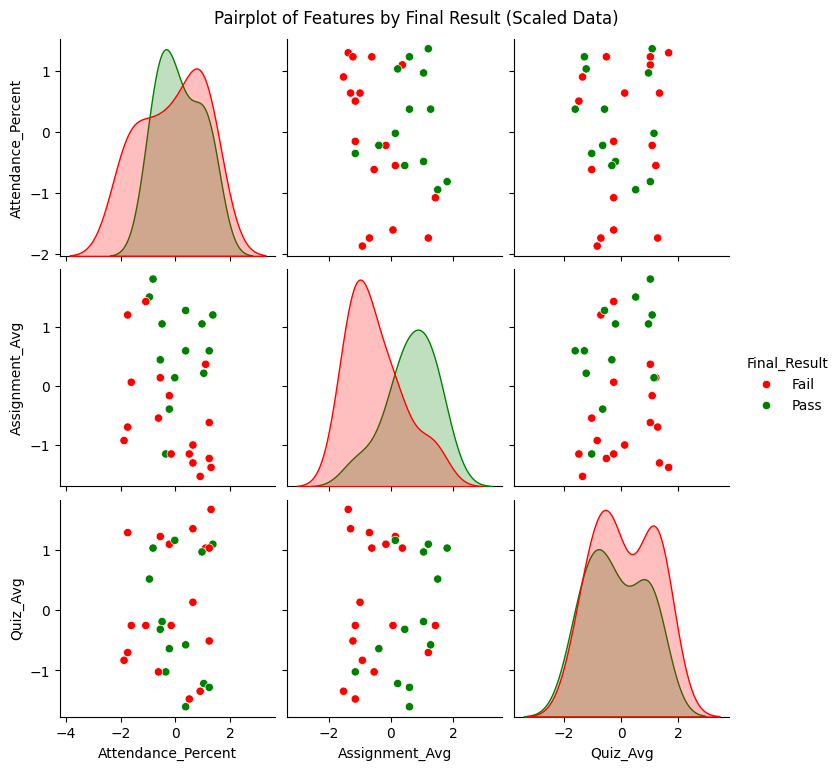

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pairplot to visualize relationships between features and the target variable
# Using 'hue' to differentiate between 'Pass' and 'Fail' will highlight the pattern
sns.pairplot(df, vars=['Attendance_Percent', 'Assignment_Avg', 'Quiz_Avg'], hue='Final_Result', palette={'Pass': 'green', 'Fail': 'red'}, diag_kind='kde')

plt.suptitle('Pairplot of Features by Final Result (Scaled Data)', y=1.02) # Add a main title
plt.show()

From these plots, you can observe that the red points (representing 'Fail') often cluster towards the lower ends of the axes in at least one of the dimensions. For instance, in the 'Attendance_Percent' vs. 'Final_Result' plot, you'll likely see a concentration of red points where 'Attendance_Percent' is low, regardless of the values of other features. The same applies to 'Assignment_Avg' and 'Quiz_Avg'. This visually reinforces the pattern we discussed earlier: a low score in any single metric can be a strong indicator of a 'Fail'.

In [3]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features to scale
numerical_features = ['Attendance_Percent', 'Assignment_Avg', 'Quiz_Avg']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical features
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Display the first few rows with scaled features
print('First 5 rows with scaled numerical features:')
display(df[numerical_features].head())

First 5 rows with scaled numerical features:


,Attendance_Percent,Assignment_Avg,Quiz_Avg
0,0.510083,-1.145090,-1.471821
1,1.305017,-1.372591,1.663798
2,-0.351096,-1.145090,-1.023876
3,-1.742231,1.205757,-0.703914
4,-0.483585,1.054090,-0.191977
